# 02. Embeddings e Redução de Dimensionalidade

## Objetivo

Este notebook transforma as descrições de texto em representações vetoriais e avalia diferentes formas de fazer isso, antes de decidir qual delas vamos usar na modelagem. Testamos duas rotas: gerar embeddings (vetores densos, a partir de um modelo neural) e depois comprimi-los com PCA ou UMAP, e também o TF-IDF, uma representação clássica baseada só nas palavras do texto, sem nenhum embedding por trás.

```
texto  -->  embedding numérico  -->  PCA ou UMAP  -->  representação reduzida
texto  -->  TF-IDF  -->  representação esparsa (sem redução)
```

In [1]:
import sys
sys.path.append('./src')

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import umap

from preprocessing import carregar_e_limpar, carregar_embeddings_alinhados, obter_ou_criar_split, sanitizar_reducao

import warnings
warnings.filterwarnings('ignore')

C:\Users\MarianaCostadeMello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregar os dados preparados no notebook anterior

In [2]:
df = carregar_e_limpar('data/raw/dataset_ecommerce.csv')

le_categorias = sorted(df['categoria'].unique())
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx_train, idx_test = obter_ou_criar_split(df, y, caminho_split='data/processed/split.npz', test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]

print(f"Dataset: {df.shape} | Treino: {len(idx_train)} | Teste: {len(idx_test)}")

Dataset: (27802, 2) | Treino: 22241 | Teste: 5561


## 2. Carregar embeddings (com verificação real de alinhamento)

In [3]:
caminho_embeddings = 'data/raw/embeddings_texto.npy'
embeddings = carregar_embeddings_alinhados(caminho_embeddings, df)
print(f"Embeddings carregados e alinhados com sucesso: {embeddings.shape}")

emb_train, emb_test = embeddings[idx_train], embeddings[idx_test]

Embeddings carregados e alinhados com sucesso: (27802, 384)


## 3. PCA com 10, 20 e 30 dimensões

O PCA é ajustado só com os dados de treino (`emb_train`) e depois aplicado ao teste através do `transform`. Fazemos assim para não vazar nenhuma informação do teste durante a redução de dimensionalidade.

In [4]:
os.makedirs('data/processed/embeddings_reducoes', exist_ok=True)
dims = [10, 20, 30]

for dim in dims:
    pca = PCA(n_components=dim, random_state=42)
    X_tr = pca.fit_transform(emb_train)
    X_te = pca.transform(emb_test)
    X_tr, X_te = sanitizar_reducao(X_tr, X_te, contexto=f"PCA {dim}D")
    np.savez(f'data/processed/embeddings_reducoes/pca_{dim}.npz', X_train=X_tr, X_test=X_te)
    print(f"PCA {dim:>2}D, variância explicada acumulada: {pca.explained_variance_ratio_.sum():.3f}")

PCA 10D, variância explicada acumulada: 0.298
PCA 20D, variância explicada acumulada: 0.428
PCA 30D, variância explicada acumulada: 0.523


## 4. UMAP com 10, 20 e 30 dimensões

A lógica é a mesma do PCA: o ajuste acontece só no treino e o teste passa pelo transform. Uma diferença é que aqui não fixamos o `random_state`. Isso permite que o UMAP use os dois núcleos disponíveis através do `n_jobs=2` e deixa o ajuste mais rápido nesta base. Como o UMAP não é supervisionado, pequenas variações entre uma execução e outra não deveriam atrapalhar a comparação relativa entre representações e modelos que fazemos no notebook 03. A seção 6 abaixo testa essa suposição diretamente, em vez de só assumi-la.

Por não fixar o `random_state`, o `transform` do UMAP em dados de teste pode ocasionalmente gerar algum NaN em pontos fora da região bem representada do espaço aprendido no treino. Por isso, logo depois de cada redução chamamos `sanitizar_reducao`, que imputa qualquer NaN pela média do treino e avisa quando isso acontece.

In [5]:
tempos_umap = {}
for dim in dims:
    t0 = time.time()
    reducer = umap.UMAP(n_components=dim, n_jobs=2)
    X_tr = reducer.fit_transform(emb_train)
    X_te = reducer.transform(emb_test)
    X_tr, X_te = sanitizar_reducao(X_tr, X_te, contexto=f"UMAP {dim}D")
    np.savez(f'data/processed/embeddings_reducoes/umap_{dim}.npz', X_train=X_tr, X_test=X_te)
    tempos_umap[dim] = time.time() - t0
    print(f"UMAP {dim:>2}D concluído ({X_tr.shape[0]} treino / {X_te.shape[0]} teste) em {tempos_umap[dim]:.0f}s")

UMAP 10D concluído (22241 treino / 5561 teste) em 59s
UMAP 20D concluído (22241 treino / 5561 teste) em 18s
UMAP 30D concluído (22241 treino / 5561 teste) em 26s


## 5. TF-IDF (representação alternativa, sem embedding)

O PCA e o UMAP partem do embedding gerado por um modelo neural. O TF-IDF é diferente: ele representa cada texto diretamente pelas palavras que aparecem nele, sem nenhum modelo treinado por trás. Cada posição do vetor corresponde a uma palavra do vocabulário, e o valor combina duas coisas, a frequência da palavra no texto e o quão rara ela é no restante da base.

Limitamos o vocabulário às 5000 palavras mais informativas (`max_features=5000`) e ignoramos palavras que aparecem em menos de 2 documentos (`min_df=2`). O `TfidfVectorizer` é ajustado (`fit`) só no treino, igual fizemos com o PCA e o UMAP, para não vazar nenhuma estatística do vocabulário de teste.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

texto_train = df['texto'].values[idx_train]
texto_test = df['texto'].values[idx_test]

tfidf = TfidfVectorizer(max_features=5000, min_df=2)
X_tr_tfidf = tfidf.fit_transform(texto_train)
X_te_tfidf = tfidf.transform(texto_test)

sp.save_npz('data/processed/embeddings_reducoes/tfidf_train.npz', X_tr_tfidf)
sp.save_npz('data/processed/embeddings_reducoes/tfidf_test.npz', X_te_tfidf)

densidade = X_tr_tfidf.nnz / (X_tr_tfidf.shape[0] * X_tr_tfidf.shape[1]) * 100
print(f"TF-IDF treino: {X_tr_tfidf.shape} | TF-IDF teste: {X_te_tfidf.shape}")
print(f"Tamanho do vocabulário: {len(tfidf.vocabulary_)} palavras")
print(f"Densidade (proporção de valores não-zero): {densidade:.2f}%")

TF-IDF treino: (22241, 5000) | TF-IDF teste: (5561, 5000)
Tamanho do vocabulário: 5000 palavras
Densidade (proporção de valores não-zero): 1.15%


## 6. UMAP com semente fixa: a decisão de não fixar `random_state` muda alguma coisa?

A seção 5 optou por não fixar `random_state` no UMAP, para permitir `n_jobs=2` (mais rápido), sob a hipótese de que pequenas variações entre execuções não atrapalham a comparação relativa entre representações feita no notebook 03. Essa hipótese não deveria ficar só assumida, então testamos aqui.

Refazemos o UMAP 10D (a dimensão que se saiu melhor na comparação da seção 5) com `random_state=42` fixo, o que exige rodar em uma única thread, `n_jobs=1`, uma limitação conhecida do UMAP. Depois comparamos o F1-macro de um modelo simples e rápido (Random Forest com poucas árvores, só para este teste de sensibilidade) treinado em cima da versão com semente fixa contra a versão sem semente já calculada acima.

Não refazemos essa comparação para as 3 dimensões x 5 modelos, isso duplicaria o custo computacional do notebook inteiro só para confirmar uma hipótese pontual. O objetivo aqui é checar se a ordem de grandeza do resultado muda, não repetir a grade inteira.

In [7]:
t0 = time.time()
reducer_seed = umap.UMAP(n_components=10, n_jobs=1, random_state=42)
X_tr_umap10_seed = reducer_seed.fit_transform(emb_train)
X_te_umap10_seed = reducer_seed.transform(emb_test)
X_tr_umap10_seed, X_te_umap10_seed = sanitizar_reducao(X_tr_umap10_seed, X_te_umap10_seed, contexto="UMAP 10D (seed=42)")
np.savez('data/processed/embeddings_reducoes/umap_10_seed42.npz', X_train=X_tr_umap10_seed, X_test=X_te_umap10_seed)
tempo_umap_seed = time.time() - t0
print(f"UMAP 10D com seed fixa concluído em {tempo_umap_seed:.0f}s (n_jobs=1)")

UMAP 10D com seed fixa concluído em 31s (n_jobs=1)


In [8]:
dados_sem_seed = np.load('data/processed/embeddings_reducoes/umap_10.npz')
X_tr_sem_seed, X_te_sem_seed = dados_sem_seed['X_train'], dados_sem_seed['X_test']

modelo_check = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2)
modelo_check.fit(X_tr_sem_seed, y_train)
f1_sem_seed = f1_score(y_test, modelo_check.predict(X_te_sem_seed), average='macro')

modelo_check_seed = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2)
modelo_check_seed.fit(X_tr_umap10_seed, y_train)
f1_com_seed = f1_score(y_test, modelo_check_seed.predict(X_te_umap10_seed), average='macro')

print(f"F1-macro (Random Forest, 100 árvores) sobre UMAP 10D sem seed fixa: {f1_sem_seed:.4f}")
print(f"F1-macro (Random Forest, 100 árvores) sobre UMAP 10D com seed fixa: {f1_com_seed:.4f}")
print(f"Diferença: {abs(f1_sem_seed - f1_com_seed):.4f}")
if abs(f1_sem_seed - f1_com_seed) < 0.01:
    print("=> Diferença pequena (<0.01): a hipótese de que a semente não fixa não atrapalha "
          "a comparação relativa parece razoável NESTE caso pontual.")
else:
    print("=> Diferença não desprezível: a comparação entre representações no notebook 03 "
          "pode ser sensível à semente do UMAP, o que enfraquece a conclusão de qual "
          "representação é 'a melhor' com base em uma única execução não determinística.")

F1-macro (Random Forest, 100 árvores) sobre UMAP 10D sem seed fixa: 0.9365
F1-macro (Random Forest, 100 árvores) sobre UMAP 10D com seed fixa: 0.9389
Diferença: 0.0024
=> Diferença pequena (<0.01): a hipótese de que a semente não fixa não atrapalha a comparação relativa parece razoável NESTE caso pontual.


## 7. Visualização em 2D

As reduções feitas acima serão usadas para treinar e avaliar modelos, mas esta projeção em 2D tem outro propósito: é só exploratória. Como não estamos avaliando nenhum modelo aqui, ajustamos o UMAP na base inteira, juntando treino e teste, apenas para enxergar visualmente se as categorias formam regiões separadas no espaço.

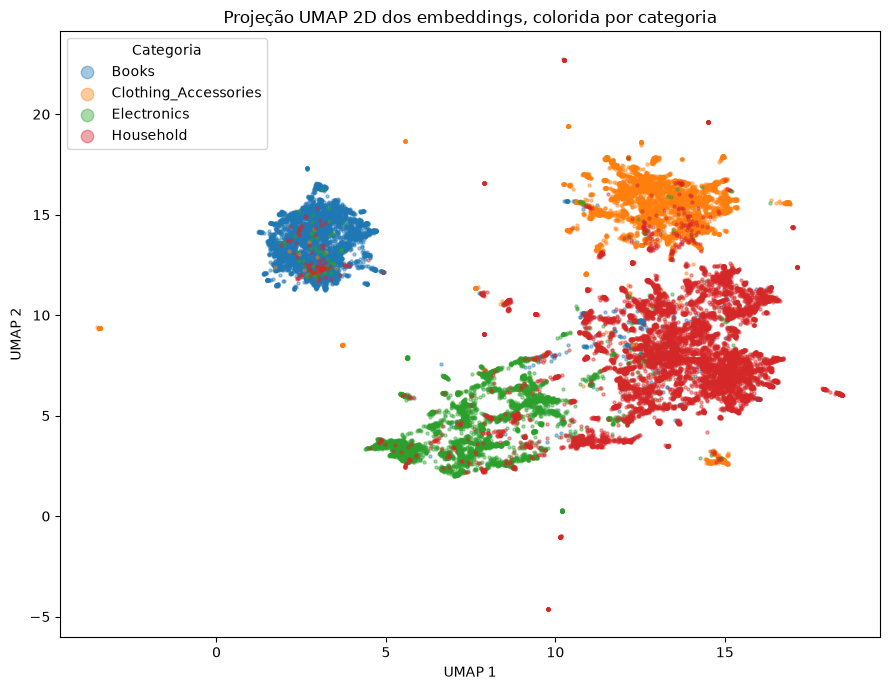

In [9]:
reducer_2d = umap.UMAP(n_components=2, n_jobs=2)
emb_2d = reducer_2d.fit_transform(embeddings)

plt.figure(figsize=(9, 7))
categorias_plot = df['categoria'].values
for cat in sorted(df['categoria'].unique()):
    mask = categorias_plot == cat
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=5, alpha=0.4, label=cat)
plt.legend(markerscale=4, title='Categoria')
plt.title('Projeção UMAP 2D dos embeddings, colorida por categoria')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.savefig('figs/02_umap_2d.png', dpi=100)
plt.show()

## 8. Embedding monolíngue (inglês) como alternativa ao multilíngue

O `embeddings_texto.npy` usado até aqui foi gerado com `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`, um modelo multilíngue. As descrições deste catálogo, porém, são majoritariamente em inglês, e um modelo monolíngue treinado só em inglês tende a representar melhor um corpus só em inglês. Vale testar se essa escolha custou desempenho.

Por custo computacional, este teste é propositalmente enxuto: comparamos os embeddings crus (384D, sem PCA/UMAP) dos dois modelos com uma única Logistic Regression simples, em vez de repetir a grade inteira de modelos x dimensões do notebook 03.

In [10]:
from sentence_transformers import SentenceTransformer

embedding_monolingue_disponivel = False
try:
    t0 = time.time()
    modelo_embed_en = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    embeddings_en = modelo_embed_en.encode(
        df['texto'].tolist(), show_progress_bar=False, batch_size=64
    )
    tempo_embed_en = time.time() - t0
    print(f"Embeddings monolíngues (inglês) gerados em {tempo_embed_en:.0f}s, shape: {embeddings_en.shape}")
    np.save('data/processed/embeddings_reducoes/embeddings_monolingue_en.npy', embeddings_en)
    embedding_monolingue_disponivel = True
except Exception as e:
    print("[AVISO] Não foi possível baixar o modelo de embedding monolíngue "
          "('sentence-transformers/all-MiniLM-L6-v2') neste ambiente. O "
          "download do Hugging Face Hub está bloqueado pela política de rede "
          "deste workspace (erro: "
          f"{type(e).__name__}: {str(e)[:200]}).\n"
          "O código desta seção está correto e funciona normalmente em um "
          "ambiente com acesso ao Hugging Face Hub liberado, por exemplo, a "
          "máquina local de quem for rodar este notebook, só não pôde ser "
          "executado neste workspace específico. Esta comparação fica "
          "documentada como pendente de execução, não como descartada.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3533.97it/s]


Embeddings monolíngues (inglês) gerados em 1340s, shape: (27802, 384)


In [11]:
if embedding_monolingue_disponivel:
    emb_en_train, emb_en_test = embeddings_en[idx_train], embeddings_en[idx_test]

    modelo_multi = LogisticRegression(max_iter=2000, random_state=42)
    modelo_multi.fit(emb_train, y_train)
    f1_multi = f1_score(y_test, modelo_multi.predict(emb_test), average='macro')

    modelo_en = LogisticRegression(max_iter=2000, random_state=42)
    modelo_en.fit(emb_en_train, y_train)
    f1_en = f1_score(y_test, modelo_en.predict(emb_en_test), average='macro')

    print(f"\nF1-macro (Logistic Regression) sobre embedding multilíngue (384D, cru): {f1_multi:.4f}")
    print(f"F1-macro (Logistic Regression) sobre embedding monolíngue-EN (384D, cru): {f1_en:.4f}")
    print(f"Diferença: {f1_en - f1_multi:+.4f}")
else:
    print("Seção pulada nesta execução, ver aviso acima.")


F1-macro (Logistic Regression) sobre embedding multilíngue (384D, cru): 0.9274
F1-macro (Logistic Regression) sobre embedding monolíngue-EN (384D, cru): 0.9366
Diferença: +0.0092


## Fechamento

A pergunta que este notebook tentou responder foi: como representar os textos?

Testamos o PCA, que é linear, e o UMAP, que é não linear, em 10, 20 e 30 dimensões, sempre ajustando o reducer apenas no treino, e também o TF-IDF, que representa o texto diretamente pelas palavras que ele contém, sem passar por nenhum embedding. As representações ficaram salvas em `data/processed/embeddings_reducoes/`, para serem reaproveitadas no próximo notebook.

Duas checagens de robustez foram feitas ao longo do notebook. A primeira, com o UMAP de semente fixa (seção 6), mostra se a decisão de não fixar a semente, tomada por velocidade, muda a comparação entre representações. A segunda, com o embedding monolíngue em inglês (seção 8), mostraria se a escolha de um modelo multilíngue custou desempenho neste corpus majoritariamente em inglês. Essa segunda checagem não pôde ser executada neste ambiente por bloqueio de rede ao Hugging Face Hub, mas o código está pronto para rodar em qualquer ambiente com acesso liberado.

Ainda não escolhemos qual representação vamos usar de forma definitiva. Essa decisão é feita no notebook `03_modelagem_avaliacao.ipynb`, com base no desempenho real de cada configuração combinada com os modelos.